In [3]:
import os
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import scipy
import torch
from sklearn import metrics

import pickle
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
import itertools
from tqdm import tqdm

import importlib
import utils
import utils_CNV
import utils_SV
warnings.filterwarnings('ignore')

/admin/software/anaconda/1.11.1/envs/jupyter/bin/python


In [125]:
importlib.reload(utils_CNV)
importlib.reload(utils_SV)
importlib.reload(utils)
from utils_CNV import *
from utils_SV import *
from utils import *

In [28]:
distance_ranges = {
    'short': (0, 17),
    'mid': (17, 45),
    'long': (45, 98),
    'ultra': (98, 200)
}

In [9]:
sv = pd.read_csv("/data1/lesliec/carolw/data_raw/data_sv.txt", sep="\t")

sv_hg38 = liftover_sv_to_hg38(sv)
sv_hg38["Site1_pos_hg38"] = sv_hg38["Site1_pos_hg38"].astype("Int64")
sv_hg38["Site2_pos_hg38"] = sv_hg38["Site2_pos_hg38"].astype("Int64")

print(sv_hg38[[
    "Site1_chr_hg38","Site1_pos_hg38",
    "Site2_chr_hg38","Site2_pos_hg38"
]].head())

  Site1_chr_hg38  Site1_pos_hg38 Site2_chr_hg38  Site2_pos_hg38
0          chr11        78652971          chr11        68286579
1          chr11        70530495          chr11        60680176
2          chr12        69362883          chr12        65094224
3           chr4        75827937           chr1       155060292
4          chr12        69925584          chr12        63590167


In [10]:
# bins that liftover fail to convert are dropped
sv_hg38 = sv_hg38.dropna(subset=["Site1_pos_hg38","Site2_pos_hg38"])

# mapped to 10kb bins
BIN = 10000
sv_hg38["Site1_bin"] = sv_hg38["Site1_pos_hg38"] // BIN
sv_hg38["Site2_bin"] = sv_hg38["Site2_pos_hg38"] // BIN

In [15]:
chrom_sizes = pd.read_csv(
    "/data1/lesliec/carolw/genome/hg38/hg38.chrom.sizes",
    sep="\t",
    header=None,
    names=["chr", "size"]
)

In [35]:
bins=create_bins_from_chrom_sizes(chrom_sizes)

In [102]:
#basal1: TCGA-BH-A0E0-01 # all in last 501 bins of chr8
#basal2: TCGA-A2-A0YJ-01
#basal3: TCGA-S3-AA0Z-01
#basal4: TCGA-AO-A124-01
sample_id = "TCGA-AO-A124-01"
sv_sample = sv_hg38[sv_hg38["Sample_Id"] == sample_id].reset_index(drop=True)

print(sv_sample.head())

         Sample_Id Site1_Hugo_Symbol Site1_Chromosome  Site1_Position  \
0  TCGA-AO-A124-01             KDM5A               12          295573   
1  TCGA-AO-A124-01           SAP30BP               17        75668625   
2  TCGA-AO-A124-01            SEMA4C                2        96863682   
3  TCGA-AO-A124-01             TESK2                1        45457564   
4  TCGA-AO-A124-01           AFG3L1P               16        89981923   

  Site2_Hugo_Symbol Site2_Chromosome  Site2_Position Site2_Effect_On_Frame  \
0             NINJ2               12          566178              in-frame   
1             KCTD2               17        75035232                   NaN   
2             WNT5B               12         1631298                   NaN   
3           GPR37L1                1       202127741              in-frame   
4             TUBB3               16        89932571                   NaN   

   Tumor_Split_Read_Count  Tumor_Paired_End_Read_Count SV_Status NCBI_Build  \
0            

In [103]:
bins_annot = annotate_sv_bins(bins, sv_sample)

In [104]:
print(bins_annot.head())

  chrom  start    end SV_category
0  chr1      0  10000  background
1  chr1  10000  20000  background
2  chr1  20000  30000  background
3  chr1  30000  40000  background
4  chr1  40000  50000  background


In [105]:
last_n = 501
sv_categories = ['SV_flank', 'SV_pair_region']

# Group by chromosome
for chrom, chrom_bins in bins_annot.groupby('chrom'):
    # Take the last 501 bins
    last_bins = chrom_bins.tail(last_n)
    
    # Count how many are SV bins
    sv_count = last_bins['SV_category'].isin(sv_categories).sum()
    
    print(f"{chrom}: {sv_count} SV bins in last {last_n} bins")

chr1: 0 SV bins in last 501 bins
chr10: 0 SV bins in last 501 bins
chr11: 0 SV bins in last 501 bins
chr12: 0 SV bins in last 501 bins
chr13: 0 SV bins in last 501 bins
chr14: 0 SV bins in last 501 bins
chr15: 0 SV bins in last 501 bins
chr16: 16 SV bins in last 501 bins
chr17: 0 SV bins in last 501 bins
chr18: 0 SV bins in last 501 bins
chr19: 0 SV bins in last 501 bins
chr2: 0 SV bins in last 501 bins
chr20: 0 SV bins in last 501 bins
chr21: 0 SV bins in last 501 bins
chr22: 0 SV bins in last 501 bins
chr3: 0 SV bins in last 501 bins
chr4: 0 SV bins in last 501 bins
chr5: 0 SV bins in last 501 bins
chr6: 0 SV bins in last 501 bins
chr7: 0 SV bins in last 501 bins
chr8: 0 SV bins in last 501 bins
chr9: 0 SV bins in last 501 bins
chrX: 0 SV bins in last 501 bins
chrY: 0 SV bins in last 501 bins


In [106]:
len(bins_annot[bins_annot["SV_category"]=='SV_pair_region'])

23771

In [107]:
len(bins_annot[bins_annot["SV_category"]=='SV_flank'])

214

In [108]:
ct = 'BRCA-DD69EDE9-142D-46E2-AA06-58D07D3230FB-X002-S04-B1-T1_H3K27ac'
ct2= 'BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1'
genome = 'hg38'
mod = 'chromafold_CTCFmotif'

#basal1:BRCA-7C6A3AE4-E2EA-42B3-B3F1-81C19E6F2170-X004-S01-B1-T1_H3K27ac
#basal1:BRCA_7C6A3AE4_E2EA_42B3_B3F1_81C19E6F2170_X005_S02_B1_T1
#basal2:BRCA-C147AAD5-A8F1-41D5-8709-21820BE50902-X005-S01-B1-T1_H3K27ac
#basal2: BRCA_C147AAD5_A8F1_41D5_8709_21820BE50902_X008_S02_B1_T1
#basal3: BRCA-CB96A542-7AC1-4FEC-A5D2-458D8EEDC6C4-X001-S01-B1-T1_H3K27ac
#basal3: BRCA_CB96A542_7AC1_4FEC_A5D2_458D8EEDC6C4_X013_S06_B1_T1
#basal4: BRCA-DD69EDE9-142D-46E2-AA06-58D07D3230FB-X002-S04-B1-T1_H3K27ac
#basal4: BRCA_DD69EDE9_142D_46E2_AA06_58D07D3230FB_X014_S08_B1_T1

In [109]:
# load ground truth HiChIP

zscore_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/zvalue/{ct}_hic_zscore_dict.p"
)

pval_path = (
    "/data1/lesliec/carolw/projects/chromafold/preprocess/BRCA-chan/hichip/"
    f"{ct}/qvalue/{ct}_hic_qvalue_dict.p"
)

with open(zscore_path, "rb") as f:
    hicdc = pickle.load(f)

with open(pval_path, "rb") as f:
    pval = pickle.load(f)

In [110]:
chrom_list = [str(i) for i in range(1, 23)]
results = evaluate_predictions_by_chrom(
    chrom_list,
    hicdc=hicdc,
    pval=pval,
    ct2=ct2,
    mod=mod,
    pred_base_path=f"/data1/lesliec/carolw/projects/chromafold/predictions/BRCA-chan_1_3k/{ct2}",
    plot=False
)


===== Chromosome 1 =====


100%|██████████████████████████████████| 24595/24595 [00:01<00:00, 13964.14it/s]



===== Chromosome 10 =====


100%|██████████████████████████████████| 13079/13079 [00:00<00:00, 38123.70it/s]



===== Chromosome 11 =====


...

100%|██████████████████████████████████| 15613/15613 [00:00<00:00, 25077.13it/s]



===== Chromosome 8 =====


100%|██████████████████████████████████| 14213/14213 [00:00<00:00, 28992.85it/s]



===== Chromosome 9 =====


100%|██████████████████████████████████| 13539/13539 [00:00<00:00, 31941.05it/s]


In [111]:
# For each bin, store a list of diagonal accuracies
bin_acc_df = create_bin_diag_accuracy_all(results, bins)
print(bin_acc_df.head())

  chrom  start    end                                           roc_list  \
0  chr1      0  10000  [0.9141988783639459, 0.9429578912945069, 0.938...   
1  chr1  10000  20000  [0.9141988783639459, 0.9429578912945069, 0.938...   
2  chr1  20000  30000  [0.9141988783639459, 0.9429578912945069, 0.938...   
3  chr1  30000  40000  [0.9141988783639459, 0.9429578912945069, 0.938...   
4  chr1  40000  50000  [0.9141988783639459, 0.9429578912945069, 0.938...   

                                        pearson_list  \
0  [0.603894336619462, 0.5904147981749401, 0.6070...   
1  [0.603894336619462, 0.5904147981749401, 0.6070...   
2  [0.603894336619462, 0.5904147981749401, 0.6070...   
3  [0.603894336619462, 0.5904147981749401, 0.6070...   
4  [0.603894336619462, 0.5904147981749401, 0.6070...   

                                            prc_list  
0  [0.6398181811996839, 0.5470807451017838, 0.579...  
1  [0.6398181811996839, 0.5470807451017838, 0.579...  
2  [0.6398181811996839, 0.547080745101783

In [112]:
metrics = ['roc', 'pearson', 'prc']

for metric in metrics:
    
    # Convert list column to matrix (n_bins × n_diag)
    mat = np.vstack(bin_acc_df[f'{metric}_list'].values).astype(float)

    # Compute means for each distance range
    for range_name, (start_idx, end_idx) in distance_ranges.items():
        
        bin_acc_df[f'{metric}_{range_name}'] = np.nanmean(
            mat[:, start_idx:end_idx],
            axis=1
        )
        
bin_acc_df.drop(columns=[f'{m}_list' for m in metrics], inplace=True)

In [113]:
active_bin_acc_df = filter_active_bins(bin_acc_df, hicdc, percentile=90)

print(active_bin_acc_df.head())

  chrom     start       end  roc_short   roc_mid  roc_long  roc_ultra  \
0  chr1  24930000  24940000   0.906122  0.822667  0.716811   0.653109   
1  chr1  26270000  26280000   0.906122  0.822667  0.716811   0.653109   
2  chr1  26600000  26610000   0.906122  0.822667  0.716811   0.653109   
3  chr1  26610000  26620000   0.906122  0.822667  0.716811   0.653109   
4  chr1  26620000  26630000   0.906122  0.822667  0.716811   0.653109   

   pearson_short  pearson_mid  pearson_long  pearson_ultra  prc_short  \
0        0.60874     0.461271       0.32046       0.202886    0.56024   
1        0.60874     0.461271       0.32046       0.202886    0.56024   
2        0.60874     0.461271       0.32046       0.202886    0.56024   
3        0.60874     0.461271       0.32046       0.202886    0.56024   
4        0.60874     0.461271       0.32046       0.202886    0.56024   

    prc_mid  prc_long  prc_ultra  
0  0.353877  0.242882   0.198407  
1  0.353877  0.242882   0.198407  
2  0.353877  0.24

In [114]:
merged_df = bins_annot.merge(active_bin_acc_df, on=['chrom','start','end'])
print(merged_df.head())

  chrom     start       end SV_category  roc_short   roc_mid  roc_long  \
0  chr1  24930000  24940000  background   0.906122  0.822667  0.716811   
1  chr1  26270000  26280000  background   0.906122  0.822667  0.716811   
2  chr1  26600000  26610000  background   0.906122  0.822667  0.716811   
3  chr1  26610000  26620000  background   0.906122  0.822667  0.716811   
4  chr1  26620000  26630000  background   0.906122  0.822667  0.716811   

   roc_ultra  pearson_short  pearson_mid  pearson_long  pearson_ultra  \
0   0.653109        0.60874     0.461271       0.32046       0.202886   
1   0.653109        0.60874     0.461271       0.32046       0.202886   
2   0.653109        0.60874     0.461271       0.32046       0.202886   
3   0.653109        0.60874     0.461271       0.32046       0.202886   
4   0.653109        0.60874     0.461271       0.32046       0.202886   

   prc_short   prc_mid  prc_long  prc_ultra  
0    0.56024  0.353877  0.242882   0.198407  
1    0.56024  0.353877  

In [115]:
len(merged_df[merged_df['SV_category'] == 'SV_flank'])

49

In [116]:
len(merged_df[merged_df['SV_category'] == 'SV_pair_region'])

1680

In [117]:
len(merged_df[merged_df['SV_category'] == 'background'])

25919

In [118]:
SVpair_bins = merged_df[merged_df['SV_category'] == 'SV_pair_region'].sample(1680)
SVflank_bins = merged_df[merged_df['SV_category'] == 'SV_flank'].sample(49)
bgd_bins = merged_df[merged_df['SV_category'] == 'background'].sample(1700)


In [119]:
compare_df = pd.concat([SVpair_bins, SVflank_bins,bgd_bins])
compare_df['sample'] = 'Basal4'
compare_df.to_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_SV_Basal4.csv", index=False)

In [120]:
compare_df2 = pd.read_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_SV_Basal2.csv")
compare_df3 = pd.read_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_SV_Basal3.csv")
compare_df4 = pd.read_csv("/data1/lesliec/carolw/projects/chromafold/vis/compare_df_SV_Basal4.csv")

all_samples_df = pd.concat(
    [compare_df2, compare_df3, compare_df4],
    ignore_index=True
)

In [123]:
sample_list = ['Basal2', 'Basal3', 'Basal4']

for sample in sample_list:
    mask = all_samples_df['sample'] == sample
    all_samples_df.loc[mask & all_samples_df['SV_category'].isin(['SV_pair_region', 'SV_flank']),
                       'SV_category'] = 'SV_region'
all_samples_df.head()

,chrom,start,end,SV_category,roc_short,roc_mid,roc_long,roc_ultra,pearson_short,pearson_mid,pearson_long,pearson_ultra,prc_short,prc_mid,prc_long,prc_ultra,sample
0,chr19,8830000,8840000,SV_region,0.859025,0.736058,0.640634,0.574027,0.581578,0.359186,0.222393,0.124638,0.464893,0.246182,0.180242,0.152175,Basal2
1,chr19,8150000,8160000,SV_region,0.859025,0.736058,0.640634,0.574027,0.581578,0.359186,0.222393,0.124638,0.464893,0.246182,0.180242,0.152175,Basal2
2,chr19,9130000,9140000,SV_region,0.859025,0.736058,0.640634,0.574027,0.581578,0.359186,0.222393,0.124638,0.464893,0.246182,0.180242,0.152175,Basal2
3,chr6,41870000,41880000,SV_region,0.870695,0.739479,0.627610,0.588507,0.574002,0.385213,0.234313,0.157938,0.483550,0.290724,0.186900,0.176461,Basal2
4,chr19,7940000,7950000,SV_region,0.859025,0.736058,0.640634,0.574027,0.581578,0.359186,0.222393,0.124638,0.464893,0.246182,0.180242,0.152175,Basal2


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:7.279e-03
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:5.132e-03
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


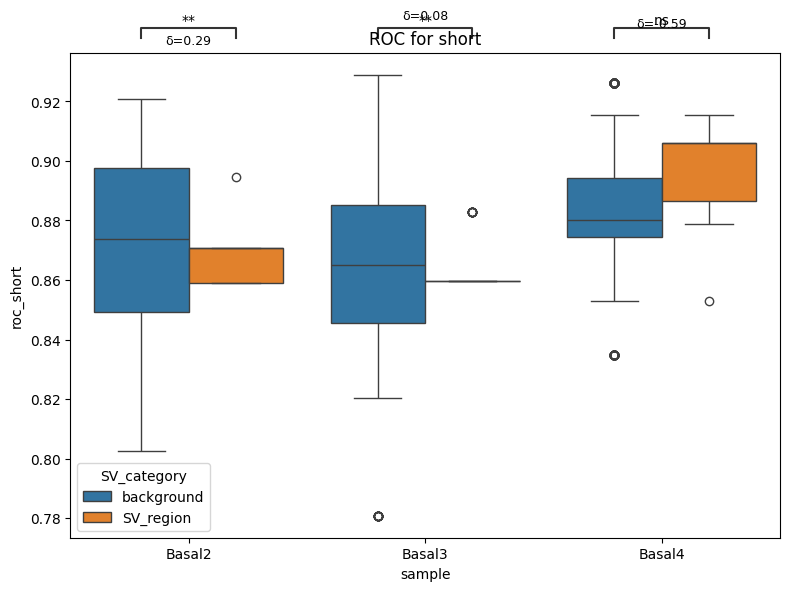

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:6.690e-03
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:7.894e-12
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


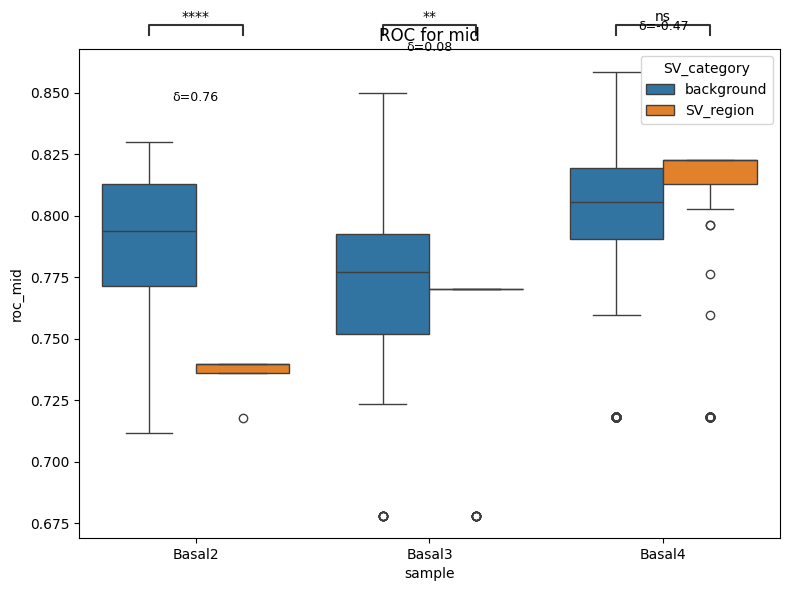

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:7.974e-15
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:1.227e-12
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


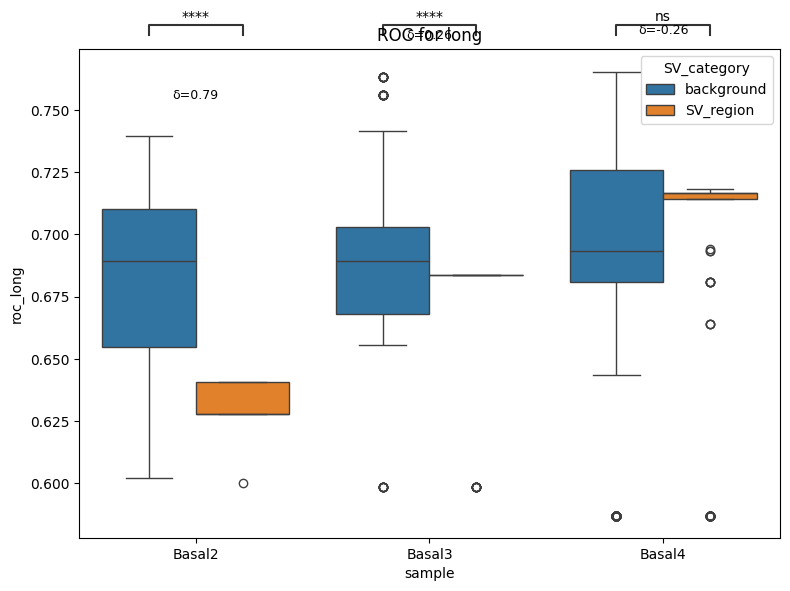

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:1.000e+00
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:1.644e-17
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


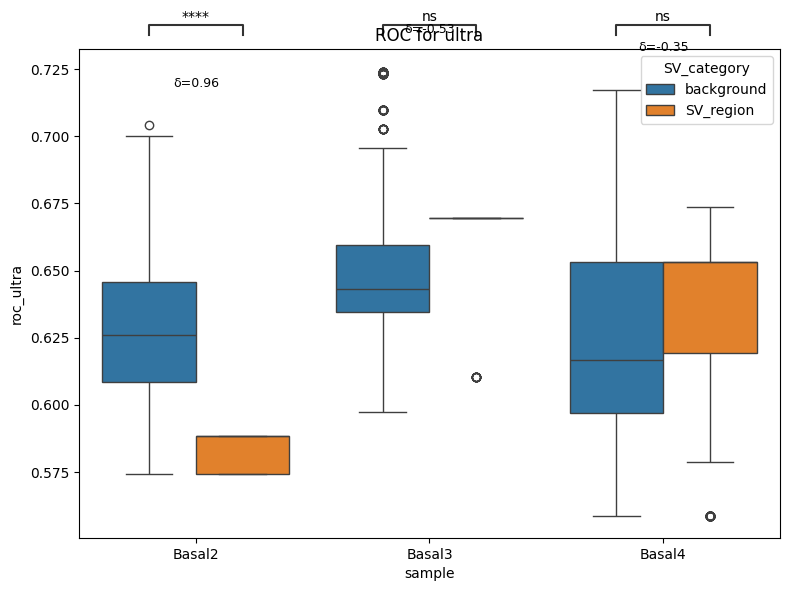

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
#from scipy.stats import brunnermunzel

plot_SV_metric_ranges_sig(all_samples_df, "roc", distance_ranges)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:1.000e+00
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:3.506e-02
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


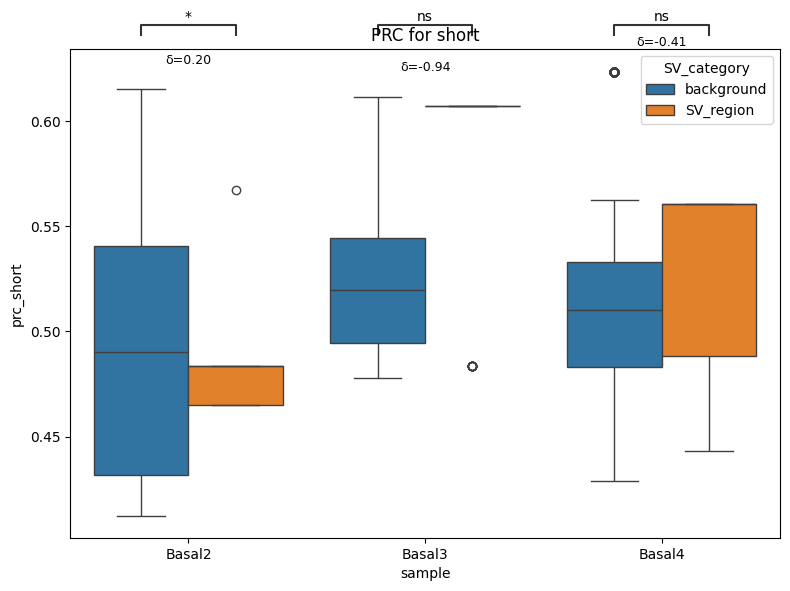

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:1.000e+00
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:2.165e-14
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


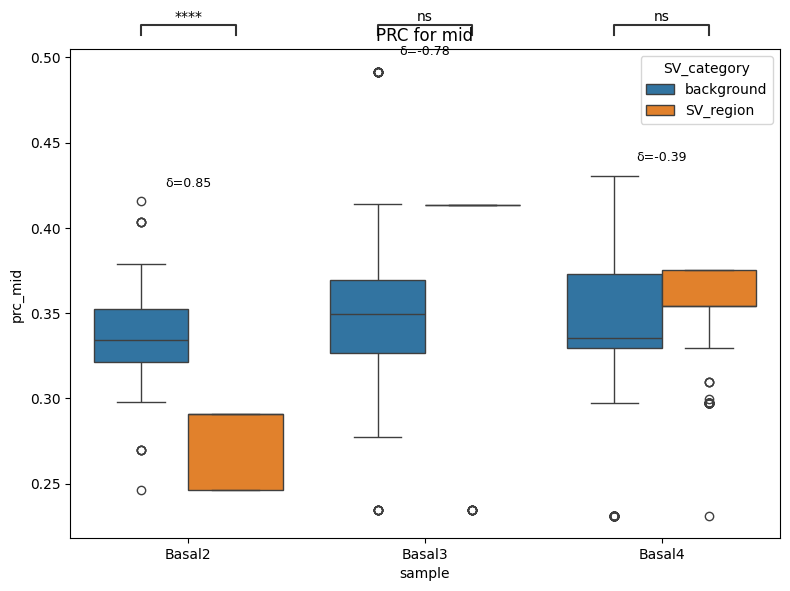

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:1.000e+00
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:8.651e-18
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


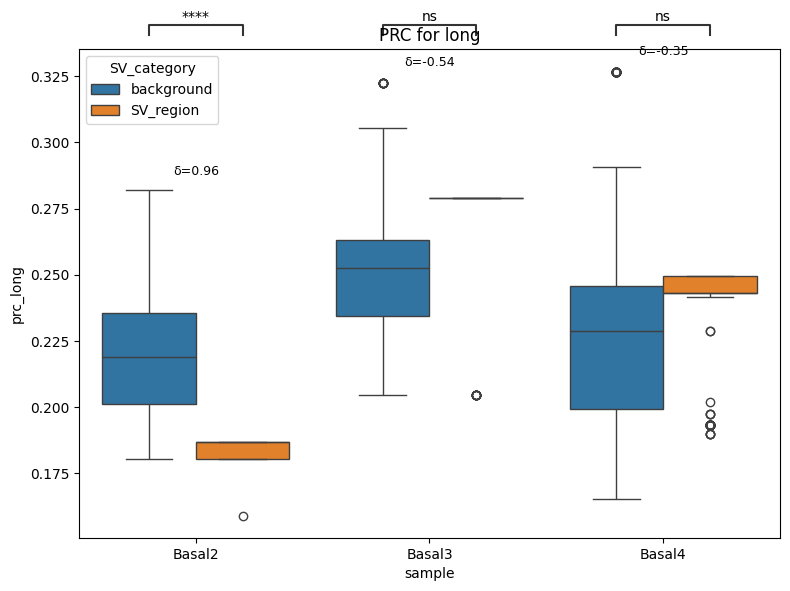

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:2.860e-103
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:3.023e-06
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


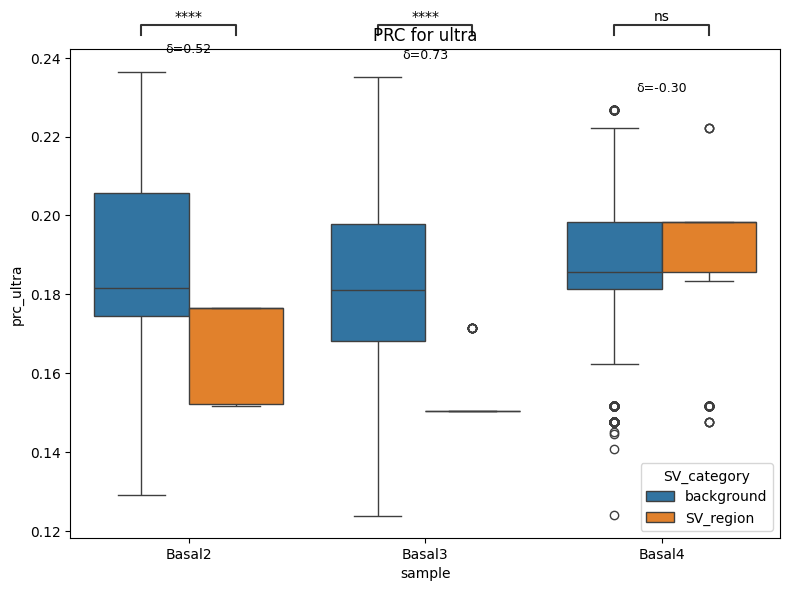

In [129]:
plot_SV_metric_ranges_sig(all_samples_df, "prc", distance_ranges)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:1.000e+00
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:5.244e-01
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


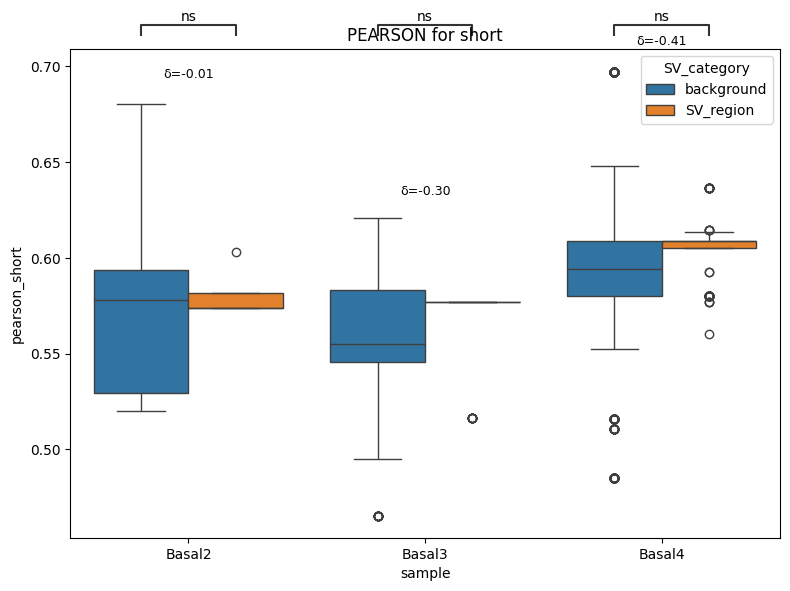

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:9.279e-01
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:2.055e-14
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


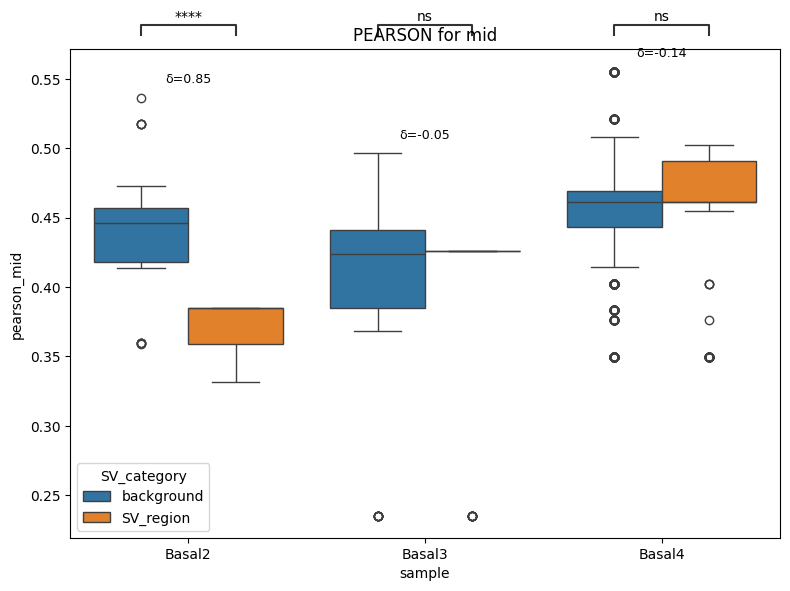

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:4.062e-169
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:6.545e-12
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


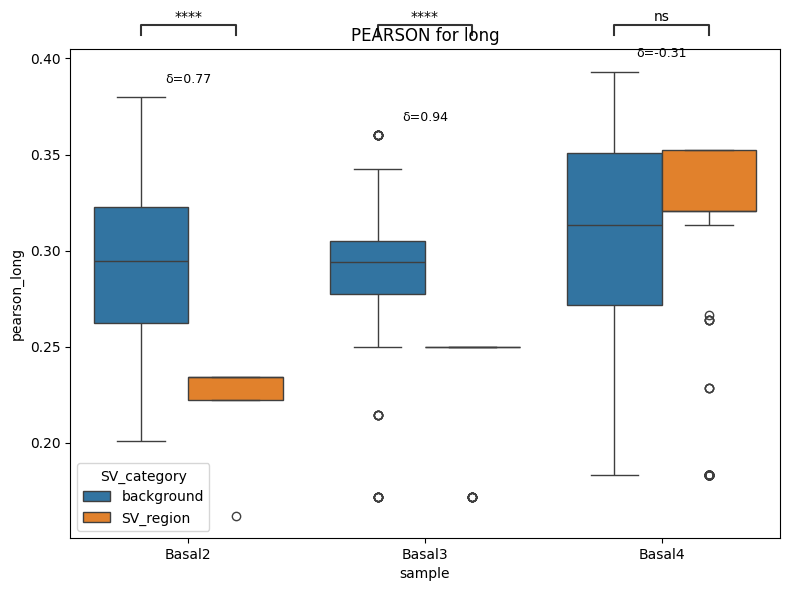

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Basal3_background vs. Basal3_SV_region: Custom statistical test, P_val:3.599e-129
Basal2_background vs. Basal2_SV_region: Custom statistical test, P_val:4.186e-06
Basal4_background vs. Basal4_SV_region: Custom statistical test, P_val:1.000e+00


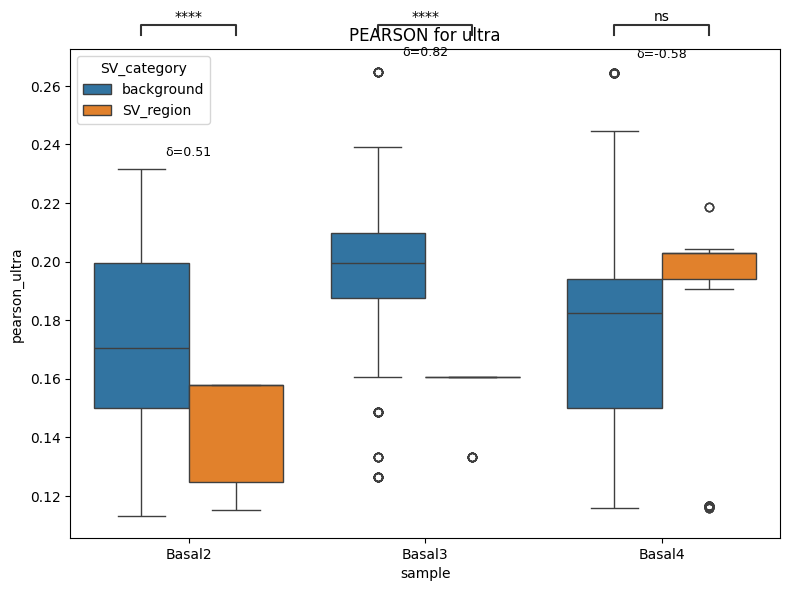

In [130]:
plot_SV_metric_ranges_sig(all_samples_df, "pearson", distance_ranges)